In [1]:
import numpy as np

#biblioteca usada para a criação, manipulação e análise de grafos
import networkx as nx 

#número de vértices
num_nodes = 5 

#Essa linha cria uma matriz de adjacência que representa o grafo
W=np.array([[0,1,1,5,5],[1,0,2,1,3],[1,2,0,5,1],[5,1,5,0,5],[5,3,1,5,0]]) 

#cria o grafo G (objeto da classe Graph) a partir da matriz de adjacência W utilizando o NetworkX
G = nx.from_numpy_array(W)

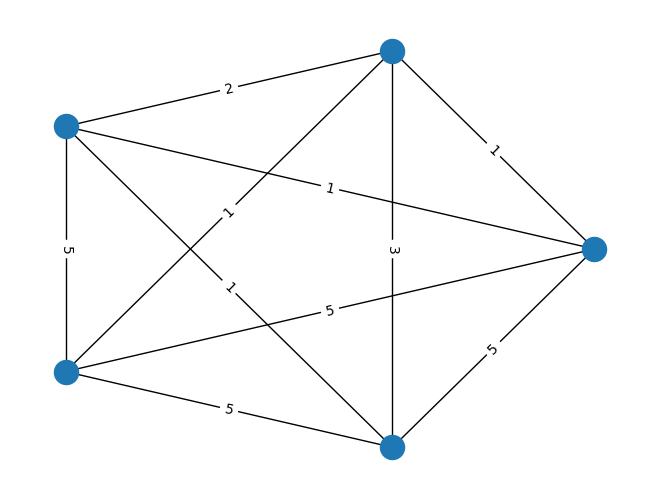

In [2]:
layout = nx.circular_layout(G) #distribuicao dos vertices
nx.draw(G, layout) #desenha o grafo
labels = nx.get_edge_attributes(G, 'weight') #pega os pesos das arestas de G e os armazena no dicionário labels
nx.draw_networkx_edge_labels(G, pos=layout, edge_labels=labels);

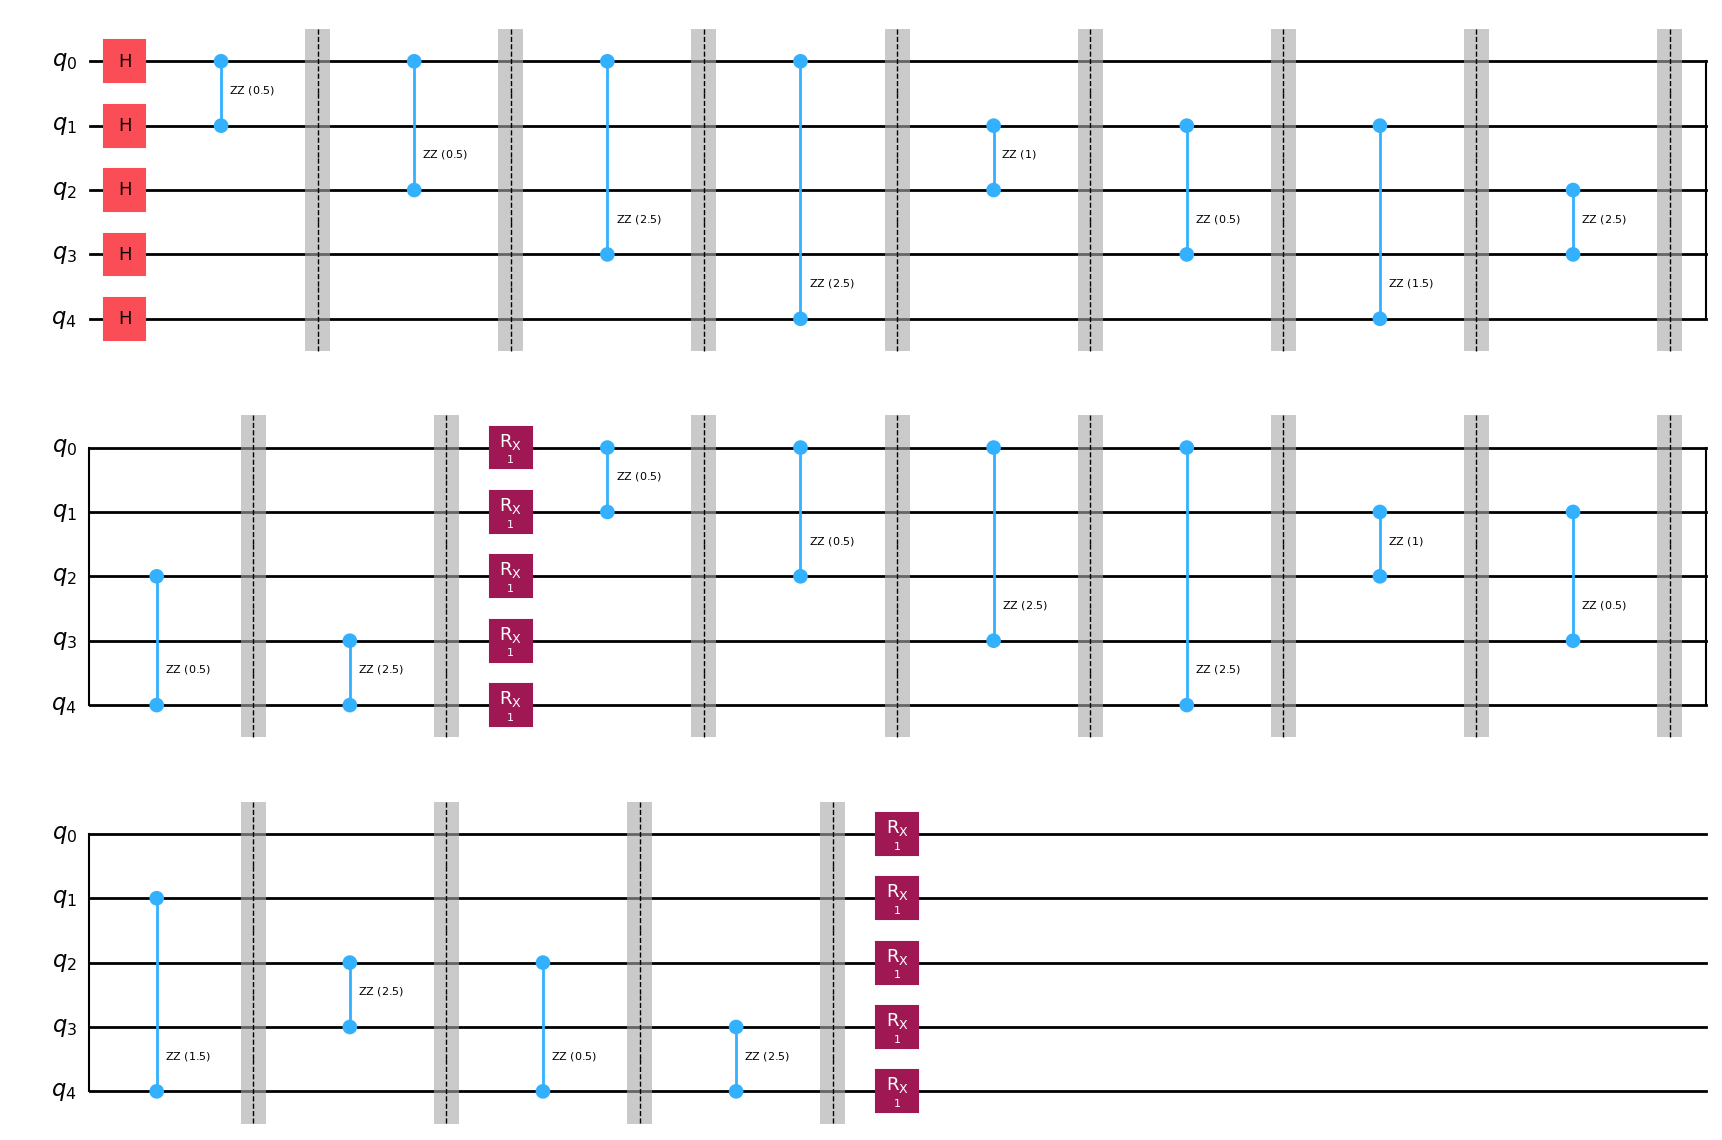

In [3]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer.aerprovider import AerSimulator
from scipy.optimize import minimize
from qiskit.visualization import plot_histogram
nqubits=5

qc = QuantumCircuit(nqubits,nqubits)

def hc(circuit, parameter):
    for i in range(0, nqubits):
        for j in range(i+1,nqubits):
            if W[i][j] != 0:
                circuit.rzz(W[i][j]*parameter,i,j)
                circuit.barrier()            
    return circuit

def mixer(circuit, parameter):
    for k in range(nqubits):
        circuit.rx(parameter*2, k)
    return circuit

def qaoa(parameter_h, parameter_m, n_layers):   
    circuit = QuantumCircuit(nqubits)
    circuit.h(range(nqubits))
    #percorre os paramentros de Hc e do Mixer onde o ZIP combina os dois conjuntos de parâmetros 
    for p_h, p_m in zip(parameter_h, parameter_m): 
        circuit = hc(circuit, p_h)
        circuit = mixer(circuit, p_m)
    #circuit.measure_all()
    return circuit

n_layers = 2
parameter_h = [0.5 for _ in range(n_layers)]
parameter_m = [0.5 for _ in range(n_layers)]
parameter = parameter_h + parameter_m

circuit = qaoa(parameter[:n_layers], parameter[n_layers:], n_layers)

circuit.draw("mpl")

In [4]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

def create_ising_hamiltonian(W):
    n = W.shape[0]  # Número de vértices/qubits
    labels = []  # Lista para guardar as strings de Pauli
    coeffs = []  # Lista para guardar os coeficientes correspondentes

    # Construir os termos do Hamiltoniano
    for i in range(n):
        for j in range(i + 1, n):
            if W[i, j] != 0:  # Só cria o termo se a interação é não nula
                # Cria uma string de Pauli com Z no i-ésimo e j-ésimo qubits
                label = ['I'] * n
                label[n-1-i] = 'Z'
                label[n-1-j] = 'Z'
                labels.append(''.join(label))
                coeffs.append(W[i, j])  # Adiciona o coeficiente negativo

    # Converter os coeficientes para um array numpy
    coeffs = np.array(coeffs)

    # Criar o SparsePauliOp
    obs = SparsePauliOp(labels, coeffs)
    return obs

# Exemplo de uso da função
W = np.array([[0, 1, 1, 5, 5], [1, 0, 2, 1, 3], [1, 2, 0, 5, 1], [5, 1, 5, 0, 5], [5, 3, 1, 5, 0]])
obs = create_ising_hamiltonian(W)
print(obs)


SparsePauliOp(['IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 5.+0.j, 5.+0.j, 2.+0.j, 1.+0.j, 3.+0.j, 5.+0.j, 1.+0.j,
 5.+0.j])


In [5]:
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime import QiskitRuntimeService

In [6]:
from qiskit import transpile
backend_aer = AerSimulator()
qc_aer = transpile(circuit,backend=backend_aer)

In [7]:
estimator_aer = EstimatorV2(mode=backend_aer)

TypeError: EstimatorV2.__init__() got an unexpected keyword argument 'mode'

In [8]:
estimator_aer = EstimatorV2(backend=backend_aer)

In [9]:
job_aer = estimator_aer.run([(qc_aer,obs,None,0.01)]) #0.01 é a precisao desejada
valor_esperado_aer = job_aer.result()[0].data.evs
print(valor_esperado_aer) 

0.6406000000000001


In [10]:
def objective_function(parameter):
    circuit = qaoa(parameter[:n_layers], parameter[n_layers:], n_layers)
    qc_aer = transpile(circuit,backend=backend_aer)
    job_aer = estimator_aer.run([(qc_aer,obs,None,0.01)]) #0.01 é a precisao desejada
    valor_esperado_aer = job_aer.result()[0].data.evs
    print(valor_esperado_aer)
    return valor_esperado_aer  

In [11]:
n_layers = 30
parameter_h = [0.5 for _ in range(n_layers)]
parameter_m = [0.5 for _ in range(n_layers)]
parameter = parameter_h + parameter_m

result = minimize(objective_function, parameter, method='COBYLA')

# Extract the optimal parameters
optimal_params = result.x

2.6572
0.46619999999999995
3.5612
-0.10079999999999995
-1.9698
-4.1154
2.7525999999999997
1.9666
-3.8334000000000006
-2.5479999999999996
-1.3707999999999998
-1.6265999999999996
3.5513999999999992
-2.5820000000000003
-3.8139999999999996
-0.7016000000000004
2.7854
5.949199999999999
-1.9687999999999997
-2.4638000000000004
-5.154400000000001
-1.8786
-0.9133999999999999
-4.739400000000001
-3.1968
-3.4814000000000007
-1.4326000000000003
0.9072
2.633
-1.3084000000000002
-0.8266000000000003
0.6397999999999997
-3.2518
3.0193999999999996
-4.3422
-1.0934000000000006
-2.047799999999999
-1.8228
-3.7872
7.003200000000001
0.4556
0.6669999999999998
-0.7065999999999999
-3.4082000000000003
-1.7591999999999999
0.41939999999999955
1.292
-4.4786
-0.17080000000000012
-0.9682
-0.1756000000000002
4.9201999999999995
-2.0366000000000004
6.8039999999999985
-2.9414
4.2276
-1.7704
0.7882
3.6342
-2.2828000000000004
-3.0844000000000005
4.8298000000000005
-1.7263999999999993
-2.7090000000000005
2.3240000000000007
-0.

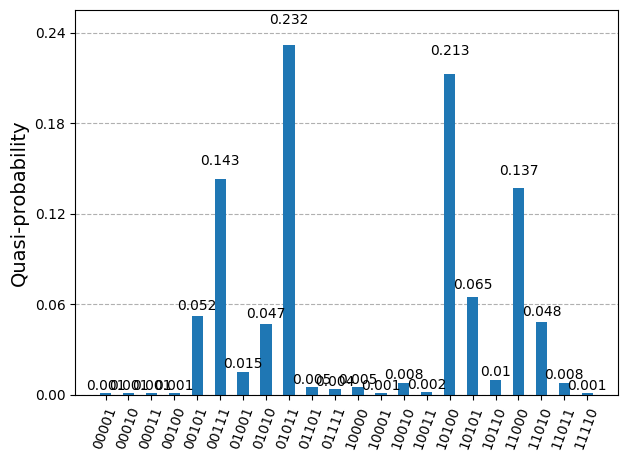

In [13]:
optimal_circuit = qaoa(optimal_params[:n_layers], optimal_params[n_layers:], n_layers)


from qiskit_ibm_runtime import SamplerV2
optimal_circuit.measure_all()
sampler = SamplerV2(backend=backend_aer)
job = sampler.run([(optimal_circuit,None,1000)])

result = job.result()
counts = result[0].data.meas.get_counts()

from qiskit.visualization import plot_distribution
plot_distribution([counts])